In [14]:
import pandas as pd

train_path = "/kaggle/input/competitions/santander-customer-satisfaction/train.csv"
test_path = "/kaggle/input/competitions/santander-customer-satisfaction/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
train_df.head()

(76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [15]:
# Separate Features and Labels
X = train_df.drop(columns=["TARGET", "ID"])
y = train_df["TARGET"]

X_test = test_df.drop(columns=["ID"])
test_ids = test_df["ID"]

In [16]:
# Remove constant columns
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

In [17]:
# Feature engineering
import numpy as np

# 1. var3 has -999999 as a "missing" sentinel; most common real value is 2
for df in (X, X_test):
    if "var3" in df.columns:
        df["var3"] = df["var3"].replace(-999999, 2)

# 2. Generic sentinel cleanup: -999999 appears across several columns
X = X.replace(-999999, np.nan)
X_test = X_test.replace(-999999, np.nan)

# 3. Clip extreme outliers using train quantiles (var38 in particular has a huge tail)
for col in X.columns:
    if X[col].dtype != "object":
        lo, hi = X[col].quantile([0.001, 0.999])
        X[col] = X[col].clip(lo, hi)
        X_test[col] = X_test[col].clip(lo, hi)

# 4. Row-wise aggregates — these are well-known to help on Santander
for df in (X, X_test):
    df["n_zeros"] = (df == 0).sum(axis=1)
    df["n_nans"] = df.isna().sum(axis=1)
    df["row_sum"] = df.sum(axis=1, skipna=True)
    df["row_mean"] = df.mean(axis=1, skipna=True)
    df["row_std"] = df.std(axis=1, skipna=True)

# 5. var38 is roughly log-normal; add a log version
if "var38" in X.columns:
    X["var38_log"] = np.log1p(X["var38"].clip(lower=0))
    X_test["var38_log"] = np.log1p(X_test["var38"].clip(lower=0))

# 6. Drop duplicate columns (Santander has several pairs of identical features)
dup_cols = []
cols = X.columns.tolist()
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        if X[c1].equals(X[c2]):
            dup_cols.append(c2)
dup_cols = list(set(dup_cols))
X = X.drop(columns=dup_cols)
X_test = X_test.drop(columns=dup_cols)

# 7. Fill remaining NaNs — tree models handle them, but LR meta-learner won't
X = X.fillna(-1)
X_test = X_test.fillna(-1)

print(f"Final shape: {X.shape}, dropped {len(dup_cols)} duplicate cols")

/tmp/ipykernel_57/3407783121.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["n_zeros"] = (df == 0).sum(axis=1)
/tmp/ipykernel_57/3407783121.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["n_nans"] = df.isna().sum(axis=1)
/tmp/ipykernel_57/3407783121.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram

Final shape: (76020, 220), dropped 121 duplicate cols


In [18]:
# Ensemble Model
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

N_SPLITS = 5
SEED = 42
# Use Stratified K Fold due to imbalanced data, ensuring each fold has a representative target distribution
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

def make_models():
    return {
        "xgb": XGBClassifier(
            n_estimators=600,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            eval_metric="auc",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
        ),
        "lgbm": LGBMClassifier(
            n_estimators=800,
            max_depth=-1,
            num_leaves=63,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            objective="binary",
            random_state=SEED,
            n_jobs=-1,
        ),
        "cat": CatBoostClassifier(
            iterations=800,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            eval_metric="AUC",
            loss_function="Logloss",
            random_seed=SEED,
            verbose=False,
        ),
    }

model_names = list(make_models().keys())
oof_preds = {name: np.zeros(len(X)) for name in model_names}
test_preds = {name: np.zeros(len(X_test)) for name in model_names}

X_values = X.values
y_values = y.values
X_test_values = X_test.values

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_values, y_values)):
    X_tr, X_val = X_values[tr_idx], X_values[val_idx]
    y_tr, y_val = y_values[tr_idx], y_values[val_idx]

    fold_models = make_models()
    for name, model in fold_models.items():
        if name == "xgb":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        elif name == "lgbm":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[__import__("lightgbm").early_stopping(50, verbose=False)])
        else:  # catboost
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                      early_stopping_rounds=50, verbose=False)

        oof_preds[name][val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds[name] += model.predict_proba(X_test_values)[:, 1] / N_SPLITS

    print(f"Fold {fold+1} done")

for name in model_names:
    print(f"{name} OOF AUC: {roc_auc_score(y, oof_preds[name]):.5f}")

# --- Option A: simple average ---
avg_oof = np.mean([oof_preds[n] for n in model_names], axis=0)
avg_test = np.mean([test_preds[n] for n in model_names], axis=0)
print(f"Simple avg OOF AUC: {roc_auc_score(y, avg_oof):.5f}")

# --- Option B: stacked logistic regression meta-learner ---
stack_train = np.column_stack([oof_preds[n] for n in model_names])
stack_test = np.column_stack([test_preds[n] for n in model_names])

meta = LogisticRegression(C=1.0, max_iter=1000)
meta.fit(stack_train, y)
stack_oof = meta.predict_proba(stack_train)[:, 1]
stack_test_pred = meta.predict_proba(stack_test)[:, 1]
print(f"Stacked OOF AUC: {roc_auc_score(y, stack_oof):.5f}")
print(f"Meta weights: {dict(zip(model_names, meta.coef_[0]))}")

final_pred = stack_test_pred  # or use avg_test if it scores better

[LightGBM] [Info] Number of positive: 2407, number of negative: 58409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13932
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039578 -> initscore=-3.189089
[LightGBM] [Info] Start training from score -3.189089


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 done
[LightGBM] [Info] Number of positive: 2407, number of negative: 58409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13947
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039578 -> initscore=-3.189089
[LightGBM] [Info] Start training from score -3.189089


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 done
[LightGBM] [Info] Number of positive: 2406, number of negative: 58410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13914
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039562 -> initscore=-3.189521
[LightGBM] [Info] Start training from score -3.189521


...

Fold 3 done
[LightGBM] [Info] Number of positive: 2406, number of negative: 58410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13920
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039562 -> initscore=-3.189521
[LightGBM] [Info] Start training from score -3.189521


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 done
[LightGBM] [Info] Number of positive: 2406, number of negative: 58410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13913
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039562 -> initscore=-3.189521
[LightGBM] [Info] Start training from score -3.189521


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5 done
xgb OOF AUC: 0.83783
lgbm OOF AUC: 0.83622
cat OOF AUC: 0.83984
Simple avg OOF AUC: 0.84044
Stacked OOF AUC: 0.84045
Meta weights: {'xgb': np.float64(4.408471500065112), 'lgbm': np.float64(4.1545695089579), 'cat': np.float64(4.298789760350903)}


Confusion matrix at threshold 0.5:
[[72849   163]
 [ 2923    85]]

Classification report at 0.5:
              precision    recall  f1-score   support

           0     0.9614    0.9978    0.9793     73012
           1     0.3427    0.0283    0.0522      3008

    accuracy                         0.9594     76020
   macro avg     0.6521    0.5130    0.5157     76020
weighted avg     0.9369    0.9594    0.9426     76020


Best F1 threshold: 0.0962 (F1 = 0.2829)

Confusion matrix at tuned threshold:
[[67929  5083]
 [ 1675  1333]]

Classification report at tuned threshold:
              precision    recall  f1-score   support

           0     0.9759    0.9304    0.9526     73012
           1     0.2078    0.4432    0.2829      3008

    accuracy                         0.9111     76020
   macro avg     0.5918    0.6868    0.6178     76020
weighted avg     0.9455    0.9111    0.9261     76020



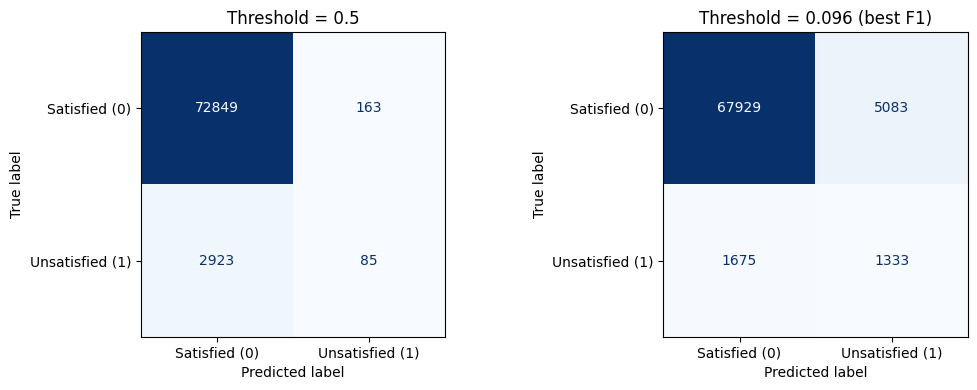

In [19]:
# Confusion matrix
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# Use the stacked OOF predictions (or swap in avg_oof if that scored better)
y_proba = stack_oof
y_true = y.values

# --- Default 0.5 threshold ---
y_pred_default = (y_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_true, y_pred_default)
print("Confusion matrix at threshold 0.5:")
print(cm_default)
print("\nClassification report at 0.5:")
print(classification_report(y_true, y_pred_default, digits=4))

# --- Tuned threshold (maximize F1 on the positive class) ---
precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1s[:-1])  # last point has no threshold
best_thresh = thresholds[best_idx]
print(f"\nBest F1 threshold: {best_thresh:.4f} (F1 = {f1s[best_idx]:.4f})")

y_pred_tuned = (y_proba >= best_thresh).astype(int)
cm_tuned = confusion_matrix(y_true, y_pred_tuned)
print("\nConfusion matrix at tuned threshold:")
print(cm_tuned)
print("\nClassification report at tuned threshold:")
print(classification_report(y_true, y_pred_tuned, digits=4))

# --- Plot both ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm_default, display_labels=["Satisfied (0)", "Unsatisfied (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Threshold = 0.5")
ConfusionMatrixDisplay(cm_tuned, display_labels=["Satisfied (0)", "Unsatisfied (1)"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title(f"Threshold = {best_thresh:.3f} (best F1)")
plt.tight_layout()
plt.show()

In [20]:
# Top features of each ensembled model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()

# Refit each model once on the full training set
full_models = make_models()
full_models["xgb"].fit(X.values, y.values, verbose=False)
full_models["lgbm"].fit(X.values, y.values)
full_models["cat"].fit(X.values, y.values, verbose=False)

# Pull importances — each library exposes them slightly differently
importances = {
    "xgb": full_models["xgb"].feature_importances_,
    "lgbm": full_models["lgbm"].feature_importances_,
    "cat": full_models["cat"].get_feature_importance(),
}

top_n = 20
top_features = {}
for name, imp in importances.items():
    df = (pd.DataFrame({"feature": feature_names, "importance": imp})
            .sort_values("importance", ascending=False)
            .head(top_n)
            .reset_index(drop=True))
    top_features[name] = df
    print(f"\n=== Top {top_n} features — {name.upper()} ===")
    print(df.to_string(index=False))

[LightGBM] [Info] Number of positive: 3008, number of negative: 73012
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14379
[LightGBM] [Info] Number of data points in the train set: 76020, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039569 -> initscore=-3.189348
[LightGBM] [Info] Start training from score -3.189348

=== Top 20 features — XGB ===
                feature  importance
              ind_var30    0.181547
               num_var4    0.081797
            saldo_var30    0.050321
                  var15    0.027387
          ind_var26_cte    0.026861
            ind_var30_0    0.018702
              ind_var13    0.016048
             ind_var8_0    0.012936
             num_var8_0    0.011181
    num_meses_var5_ult3    0.010530
imp_op_var39_e

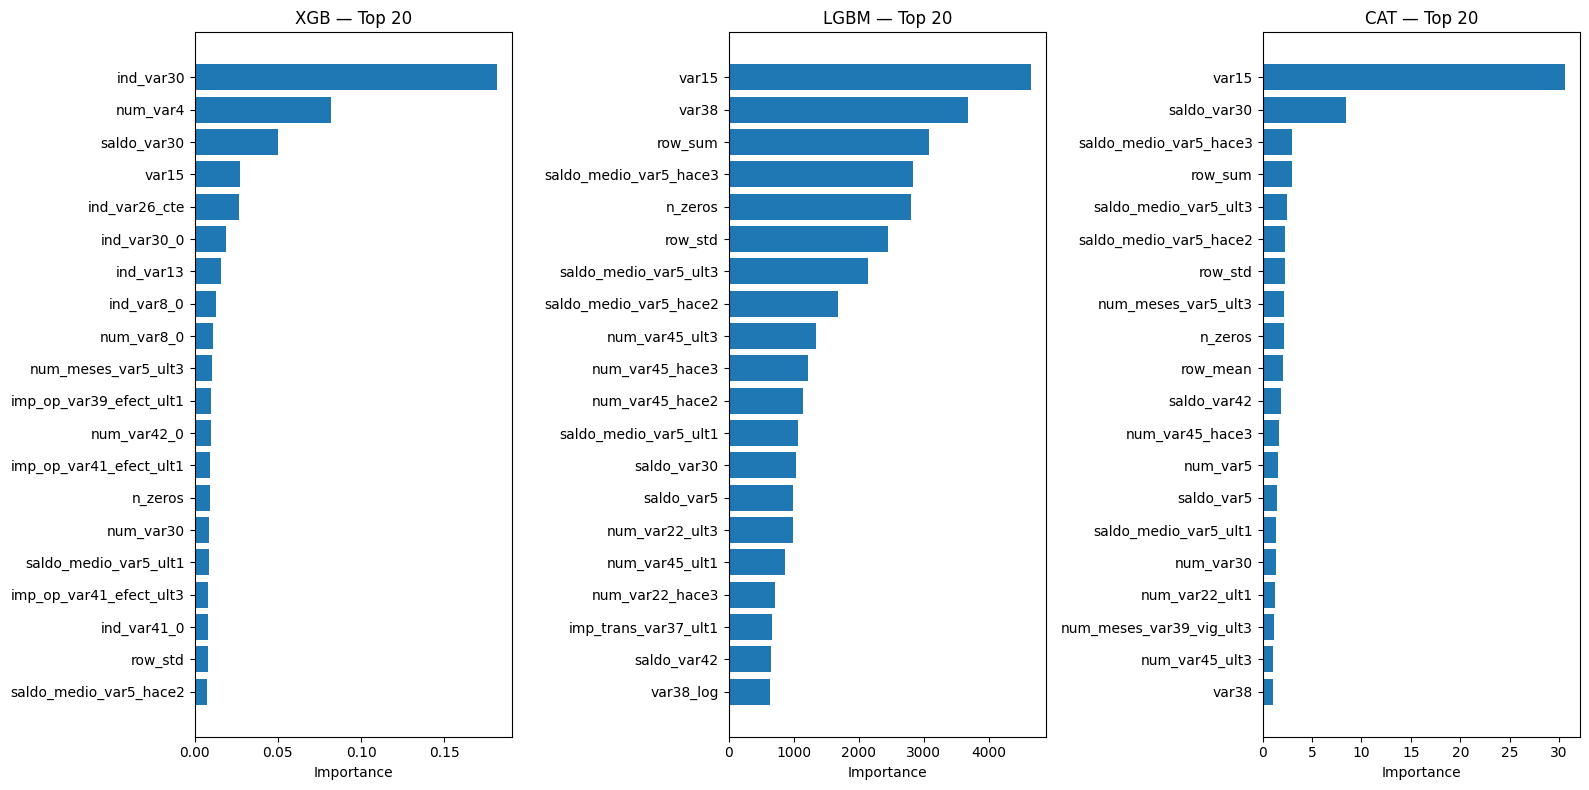

In [22]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, (name, df) in zip(axes, top_features.items()):
    ax.barh(df["feature"][::-1], df["importance"][::-1])
    ax.set_title(f"{name.upper()} — Top {top_n}")
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

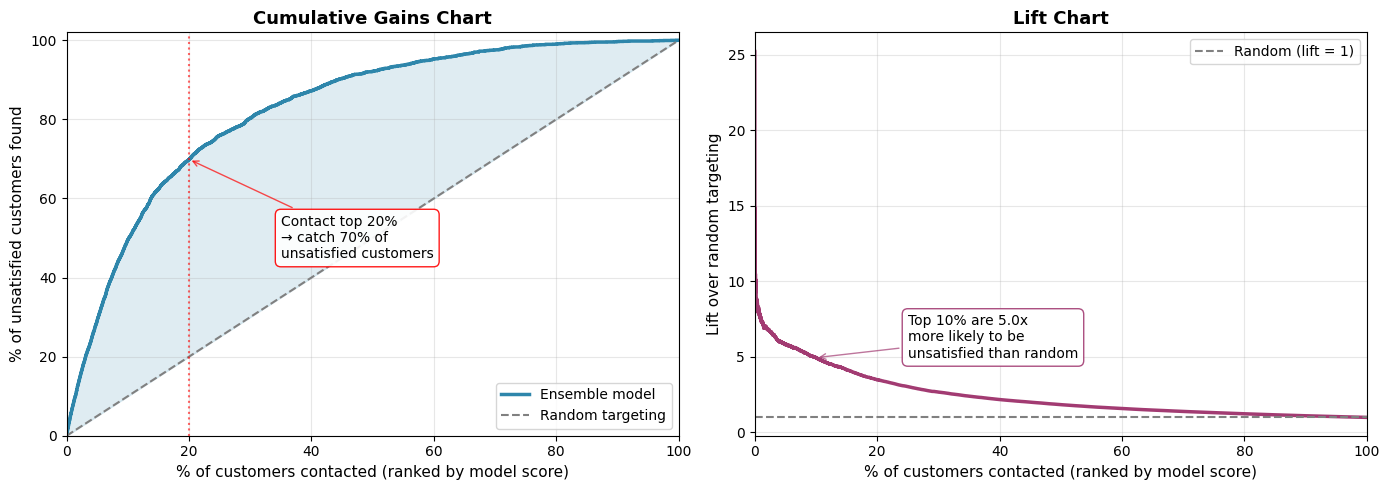

In [23]:
# Lift chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_proba = stack_oof
y_true = y.values

# Sort customers by predicted probability, highest first
order = np.argsort(-y_proba)
y_sorted = y_true[order]

n = len(y_sorted)
total_positives = y_sorted.sum()

# Cumulative captures as we move down the sorted list
cum_positives = np.cumsum(y_sorted)
percent_population = np.arange(1, n + 1) / n
percent_positives_captured = cum_positives / total_positives
random_baseline = percent_population
lift = percent_positives_captured / np.where(percent_population == 0, 1, percent_population)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Cumulative Gains Chart ---
ax = axes[0]
ax.plot(percent_population * 100, percent_positives_captured * 100,
        label="Ensemble model", linewidth=2.5, color="#2E86AB")
ax.plot([0, 100], [0, 100], "--", color="gray", label="Random targeting")
ax.fill_between(percent_population * 100, random_baseline * 100,
                percent_positives_captured * 100, alpha=0.15, color="#2E86AB")
ax.set_xlabel("% of customers contacted (ranked by model score)", fontsize=11)
ax.set_ylabel("% of unsatisfied customers found", fontsize=11)
ax.set_title("Cumulative Gains Chart", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)

# Annotate a useful operating point — the top 20%
idx_20 = int(0.20 * n)
captured_at_20 = percent_positives_captured[idx_20] * 100
ax.axvline(20, color="red", linestyle=":", alpha=0.6)
ax.annotate(
    f"Contact top 20%\n→ catch {captured_at_20:.0f}% of\nunsatisfied customers",
    xy=(20, captured_at_20), xytext=(35, captured_at_20 - 25),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", color="red", alpha=0.7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="red", alpha=0.9)
)

# --- Lift Chart ---
ax = axes[1]
ax.plot(percent_population * 100, lift, linewidth=2.5, color="#A23B72")
ax.axhline(1, linestyle="--", color="gray", label="Random (lift = 1)")
ax.set_xlabel("% of customers contacted (ranked by model score)", fontsize=11)
ax.set_ylabel("Lift over random targeting", fontsize=11)
ax.set_title("Lift Chart", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)

lift_at_10 = lift[int(0.10 * n)]
ax.annotate(
    f"Top 10% are {lift_at_10:.1f}x\nmore likely to be\nunsatisfied than random",
    xy=(10, lift_at_10), xytext=(25, lift_at_10),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", color="#A23B72", alpha=0.7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#A23B72", alpha=0.9)
)

plt.tight_layout()
plt.show()

In [7]:
submission = pd.DataFrame({"ID": test_ids, "TARGET": final_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,ID,TARGET
0,2,0.030514
1,5,0.036053
2,6,0.017060
3,7,0.018917
4,9,0.017068
